Opening container: /Users/sylvi/topo_data/temp/20251209_TAF_pICOz_MQ_50_percent_damage.0_00010.topostats
  -> Found 2 molecule dataset tracks inside Grain 1: ['0', '1']


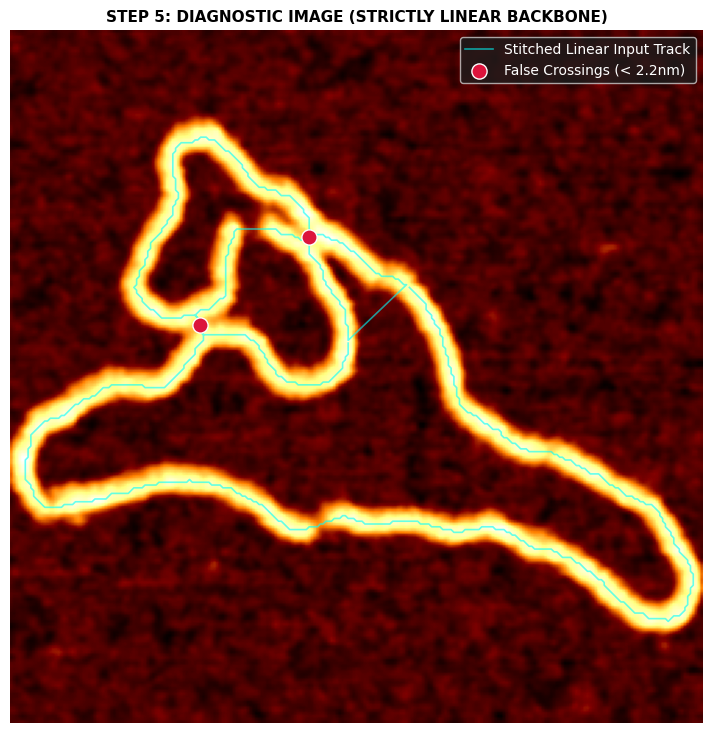


--- REPAIRING STRUCTURES WITH HEIGHT GUARDRAILS ---
Leaving 0 True Crossings completely intact.
Validating paths for 2 False Crossings...
Junction Center (np.float64(67.82142857142857), np.float64(142.46428571428572)): Optimal option is 'Configuration 3 (Crossover Variant 2)' with a minimum ridge height of 1.73 nm
Junction Center (np.float64(107.0), np.float64(174.05555555555554)): Optimal option is 'Configuration 2 (Crossover Variant 1)' with a minimum ridge height of 1.75 nm


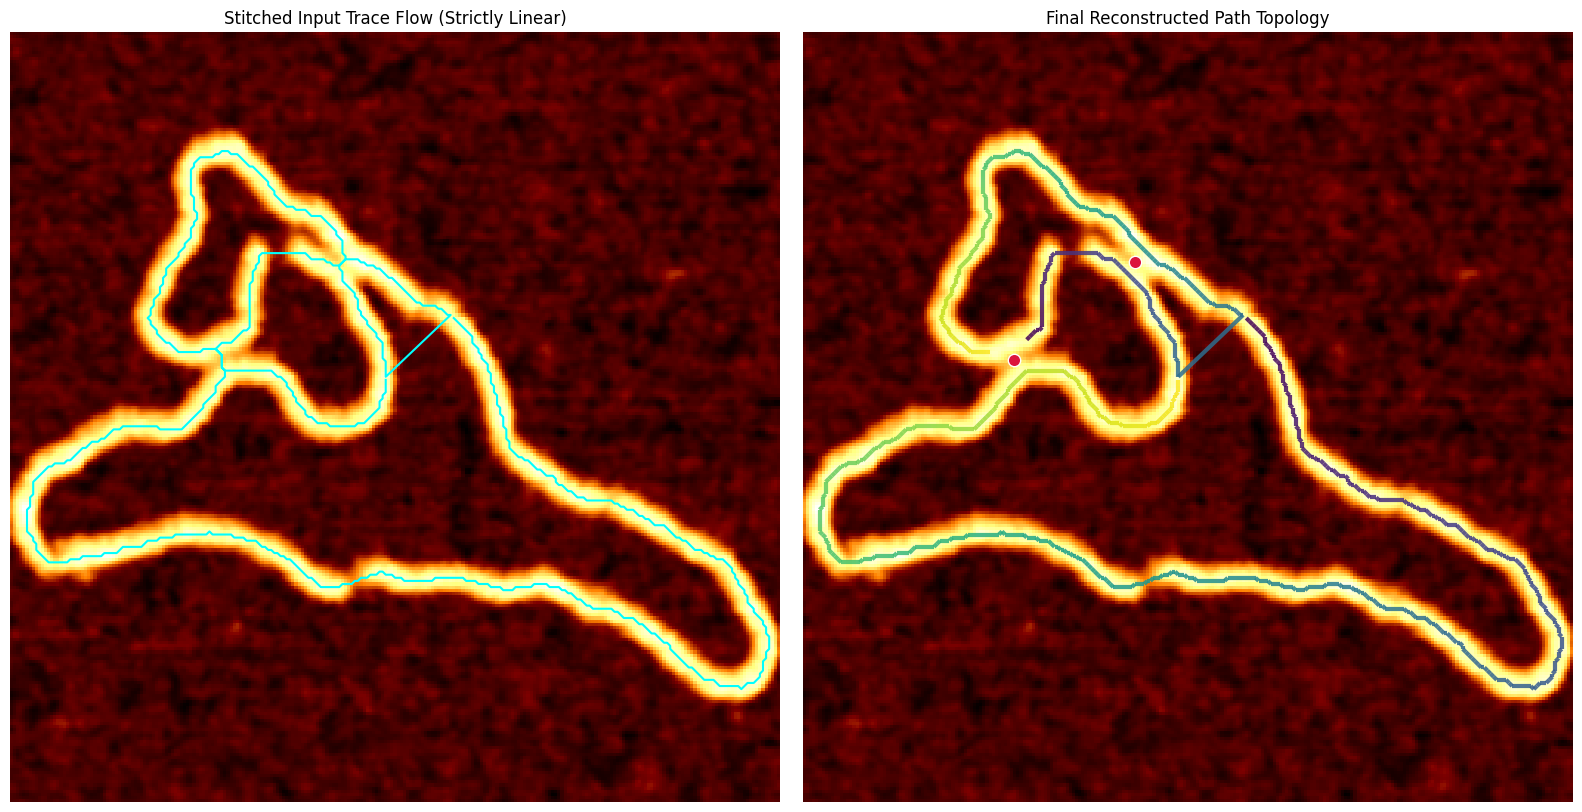

In [ ]:
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from skimage.graph import route_through_array
from matplotlib.collections import LineCollection
from pathlib import Path
import copy

# =====================================================================
# 0. TUNABLE PARAMETERS & FILE HANDLING
# =====================================================================
# DATA_DIR = Path("/Volumes/shared/pyne_group/Shared/AFM_Data/dna_damage/Cs137_irradiations/20260204-analysis-getting-back-into-the-project/output/")
# IMAGE_FILE = "MilliQ/50_percent_damage/processed/20251209_TAF_pICOz_MQ_50_percent_damage.0_00002.topostats"

DATA_DIR = Path("/Users/sylvi/topo_data/temp/")
IMAGE_FILE = "20251209_TAF_pICOz_MQ_50_percent_damage.0_00010.topostats"
FILE_PATH = DATA_DIR / IMAGE_FILE
GRAIN_IDX = "1"

MIN_PHYSICAL_DISTANCE = (
    1  # Minimum physical distance (in pixels) to consider two segments as separate strands at a crossing
)
LOOKAHEAD = 3  # Number of points to look ahead/behind when identifying crossing segments
SEARCH_RADIUS_PIXELS = 5  # Radius (in pixels) around the junction center to search for the local maximum height

# --- Pathfinding & Height Parameters ---
RIDGE_PENALTY_EXPONENT = 4.0  # Exponent to amplify the cost of traversing through brighter (higher) pixels, encouraging paths to follow darker ridges
BASE_WANDER_COST = 0.01  # Base cost added to all pixels to prevent zero-cost paths and encourage more direct routing
HEIGHT_THRESHOLD_NM = (
    2.2  # Minimum height (in nm) to classify a crossing as a true strand crossover vs a false crossing
)
STRAND_MIN_HEIGHT_NM = 1.0  # Minimum height (in nm) required for any new path segment to be added to the graph, acting as a guardrail against adding paths through very low regions
Z_SCALE = (
    1.0  # Scaling factor to convert pixel intensity to physical height in nm, adjust based on your image calibration
)

# Smart Extension Guard
target_path = Path(FILE_PATH)
if not target_path.exists():
    for ext in [".topostats", ".hdf5", ".h5"]:
        alt = target_path.with_suffix(ext)
        if alt.exists():
            FILE_PATH = str(alt)
            break

# =====================================================================
# 1. DYNAMIC MULTI-MOLECULE LOADING & STITCHING
# =====================================================================
IMAGE_PATH = f"grain_crops/{GRAIN_IDX}/image"
MOL_BASE_PATH = f"grain_crops/{GRAIN_IDX}/ordered_trace/molecule_data"

print(f"Opening container: {FILE_PATH}")

with h5py.File(FILE_PATH, "r") as f:
    image = f[IMAGE_PATH][:].squeeze()
    if image.ndim == 3:
        image = image[:, :, 0]

    if MOL_BASE_PATH in f:
        mol_keys = sorted(list(f[MOL_BASE_PATH].keys()), key=lambda x: int(x))
        print(f"  -> Found {len(mol_keys)} molecule dataset tracks inside Grain {GRAIN_IDX}: {mol_keys}")
    else:
        raise KeyError(f"Path '{MOL_BASE_PATH}' not found in the file.")

    all_traces = []
    for m_idx in mol_keys:
        c_path = f"{MOL_BASE_PATH}/{m_idx}/ordered_coords"
        if c_path in f:
            all_traces.append(f[c_path][:])

if not all_traces:
    raise ValueError(f"No valid 'ordered_coords' traces found inside {MOL_BASE_PATH}")

# Stitch disconnected molecule traces cleanly by linking closest endpoints
stitched_coords = [all_traces[0]]  # stitched_coords is the list of traces that have been stitched together so far
# in the form of a list of arrays where each array is the coord of a point in the trace
unvisited_traces = all_traces[1:]

# find the closest (euclidean) endpoint of any unvisited trace to the current stitched trace's tail and connect it
while unvisited_traces:
    current_trace = stitched_coords[-1]
    tail_pt = current_trace[-1]  # get the last point in the current stitched trace for finding the
    # next closest point to connect.

    best_next_idx = 0
    best_dist = np.inf  # distance to the closest endpoint of the next trace,
    reverse_needed = False

    for idx, next_trace in enumerate(unvisited_traces):
        head_dist = np.linalg.norm(tail_pt - next_trace[0])
        tail_dist = np.linalg.norm(tail_pt - next_trace[-1])

        if head_dist < best_dist:
            best_dist = head_dist
            best_next_idx = idx
            reverse_needed = False

        if tail_dist < best_dist:
            best_dist = tail_dist
            best_next_idx = idx
            reverse_needed = True

    next_match = unvisited_traces.pop(best_next_idx)
    # if the closest endpoint is the tail of the next trace, reverse it.
    if reverse_needed:
        next_match = next_match[::-1]

    stitched_coords.append(next_match)

# Flatten components into a single coherent linear tracing array
coords = np.vstack(stitched_coords)

y = coords[:, 0]
x = coords[:, 1]
N = len(x)
points = np.column_stack((x, y))

# Cost Map for Ridge Pathfinding
img_min, img_max = image.min(), image.max()
img_norm = (image - img_min) / (img_max - img_min + 1e-8)
cost_image = (1.0 - img_norm) ** RIDGE_PENALTY_EXPONENT + BASE_WANDER_COST


# =====================================================================
# 2. TOPOLOGICAL GRAPH FUNCTIONS (CIRCULARITY REMOVED)
# =====================================================================
def create_base_graph():
    """Initializes a strictly open, sequential linear network topology."""
    graph = {i: {} for i in range(N)}
    for i in range(N - 1):
        graph[i][i + 1] = []
        graph[i + 1][i] = []
    # FIXED: Ring-closure graph hooks completely removed
    return graph


def remove_segment(graph, u, v):
    for i in range(u, v):
        # remove the edges between the nodes in the original linear path
        # indexing by i and i+1 ensures we are removing the correct segment of the original path as we
        # traverse from u to v, since each time an edge is removed, the index of the next node shifts by 1.
        if i + 1 in graph[i]:
            del graph[i][i + 1]
        if i in graph[i + 1]:
            del graph[i + 1][i]


def evaluate_route_height(n1, n2):
    # get the start and end coords for the route from the input points, where n1 and n2 are indices of the points.
    start_idx = (int(np.round(points[n1, 1])), int(np.round(points[n1, 0])))
    end_idx = (int(np.round(points[n2, 1])), int(np.round(points[n2, 0])))
    start_idx = (max(0, min(start_idx[0], image.shape[0] - 1)), max(0, min(start_idx[1], image.shape[1] - 1)))
    end_idx = (max(0, min(end_idx[0], image.shape[0] - 1)), max(0, min(end_idx[1], image.shape[1] - 1)))
    try:
        path_coords, _ = route_through_array(cost_image, start_idx, end_idx, fully_connected=True)
        heights = [image[py, px] for py, px in path_coords]
        return float(np.min(heights)) * Z_SCALE
    except:
        return 0.0


def add_ridge_path(graph, n1, n2):
    # add the path between n1 and n2 to the graph
    start_idx = (int(np.round(points[n1, 1])), int(np.round(points[n1, 0])))
    end_idx = (int(np.round(points[n2, 1])), int(np.round(points[n2, 0])))
    start_idx = (max(0, min(start_idx[0], image.shape[0] - 1)), max(0, min(start_idx[1], image.shape[1] - 1)))
    end_idx = (max(0, min(end_idx[0], image.shape[0] - 1)), max(0, min(end_idx[1], image.shape[1] - 1)))
    try:
        path_coords, _ = route_through_array(cost_image, start_idx, end_idx, fully_connected=True)
        path_xy = np.array(path_coords)[:, ::-1]
    except:
        path_xy = np.vstack([points[n1], points[n2]])

    # exclude the endpoitns of the path since they are already in the graph.
    inner_path = path_xy[1:-1] if len(path_xy) > 2 else []
    graph[n1][n2] = inner_path
    graph[n2][n1] = inner_path[::-1] if len(inner_path) > 0 else []


def traverse_graph(graph_dict):
    # graph dict has structure {node_index: {connected_node_index: [intermediate_points], ...}, ...} ???
    comps = []  # list of components - each component is a list of points that are connected in the graph.
    vst = set()  # visited nodes in the graph traversal
    # iterate until all nodes in the graph have been visited, building components as it is traversed.
    while len(vst) < len(graph_dict):
        # calculate the unvisited nodes that have at least one connection to another node
        unv = [i for i in graph_dict if i not in vst and len(graph_dict[i]) > 0]
        if len(unv) == 0:
            break
        # calculate the tips of the unvisited nodes - these are nodes that only have one connection to another node
        tips = [i for i in unv if len([n for n in graph_dict[i] if n not in vst]) == 1]
        # if there are any tips, start the traversal from the first tip, otherwise start from the first unvisited node
        # with at least one connection
        curr = tips[0] if len(tips) > 0 else unv[0]  # curr is an index of the current node
        trace = [points[curr]]  # beginning the trace with the current node's point
        vst.add(curr)  # add the current node to the visited set ofc

        # traverse the graph by repeatedly looking for the next unvisited node that is connected to the current node,
        # adding its point to the trace and marking it as visited, until there are no more unvisited connected nodes
        # to the current node.
        while True:
            # next unvisited connected node to the current node, or None if there are no unvisited connected nodes
            nxt = next((n for n in graph_dict[curr] if n not in vst), None)
            if nxt is None:
                break  # cancel the loop if there are no more unvisited connected nodes ofc.
            mid = graph_dict[curr][nxt]  # grab the intermediate points between the current node and next node
            if len(mid) > 0:
                trace.extend(mid)  # add the intermediate points to the trace if they exist.
            trace.append(points[nxt])  # add the next node's point to the trace
            vst.add(nxt)  # update visited nodes with the next node
            curr = nxt  # set the current node to the next node
            # repeat until there are no unvisited connected nodes to the current node.
        # finally add the trace to the components list if it has more than 1 point
        if len(trace) > 1:
            comps.append(np.array(trace))
    return comps


def add_vector_dilated_crossover(graph, n1, n2, n3, n4, peak_rc, image):
    peak_xy = np.array([peak_rc[1], peak_rc[0]], dtype=float)
    outer_nodes = [n1, n2, n3, n4]

    # get the vectors from each node to the peak and normalise to unit length
    vectors = {}
    for n in outer_nodes:
        vec = peak_xy - points[n]
        dist = np.linalg.norm(vec)
        vectors[n] = vec / dist if dist > 1e-5 else np.array([0.0, 0.0])

    # make a list of the 3 possible configurations of pairs in the 4 node system
    possible_configs = [
        ((outer_nodes[0], outer_nodes[1]), (outer_nodes[2], outer_nodes[3])),
        ((outer_nodes[0], outer_nodes[2]), (outer_nodes[1], outer_nodes[3])),
        ((outer_nodes[0], outer_nodes[3]), (outer_nodes[1], outer_nodes[2])),
    ]

    # find the configuration of pairs of nodes that have the smallest combined dot product of their vectors to the peak
    # ie, where we take the dot product of the vector from each node to the peak with the vector from the other node
    # in the pair and sum these for the two pairs in the configuration, find the configuration that minimises this.
    best_pairs = None
    min_dot = np.inf
    for pair1, pair2 in possible_configs:
        combined_dot = np.dot(vectors[pair1[0]], vectors[pair1[1]]) + np.dot(vectors[pair2[0]], vectors[pair2[1]])
        if combined_dot < min_dot:
            min_dot = combined_dot
            best_pairs = (pair1, pair2)

    # get the start and ends of the two strands from the best pair
    strand1_start, strand1_end = best_pairs[0]
    strand2_start, strand2_end = best_pairs[1]

    def generate_backbone_following_leg(n_outer):
        # n_outer is the index of the outer node that a "leg" needs generating from to the peak
        # a leg is the set of points that form the path from the outer node to the peak
        p_outer = points[n_outer]  # the coordinate of the outer node
        dist_to_peak = np.linalg.norm(peak_xy - p_outer)  # euclidean distance from the outer ndoe to the peak
        num_steps = max(int(dist_to_peak * 2.0), 5)  # number of steps ??? minimum 5, or 2 * the distance in
        # pixels (euvlidean) to the peak from the node.

        leg_pts = []
        for i in range(num_steps):
            t = i / (num_steps - 1)  # interpolation factor from 0 to 1 along the line
            base_pt = (1 - t) * p_outer + t * peak_xy  # the point along the line at this interpolation factor

            # add the node itself or the peak itself at the start / end of the iteration.
            if i == 0:
                leg_pts.append(p_outer)
                continue
            if i == num_steps - 1:
                leg_pts.append(peak_xy)
                continue

            segment_dir = peak_xy - p_outer  # vector from the outer node to the peak
            dir_len = np.linalg.norm(segment_dir)
            # normalise it ofc.
            normal = np.array([-segment_dir[1], segment_dir[0]]) / dir_len if dir_len > 1e-5 else np.array([1.0, 0.0])

            # search along the normal in both directions for the point with the highest intensity in the image
            # so we follow the highest region reasonably.
            best_pt = base_pt
            max_intensity = -np.inf
            # try a fixed set of offsets along the normal
            search_offsets = [-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5]
            for offset in search_offsets:
                # taper the offset as proximity to the peak increases, so it doesn't form a discontinuity
                tapered_offset = offset * (1 - t)
                test_pt = base_pt + (normal * tapered_offset)
                px = int(np.round(test_pt[0]))
                py = int(np.round(test_pt[1]))

                if 0 <= py < image.shape[0] and 0 <= px < image.shape[1]:
                    intensity = image[py, px]
                    if intensity > max_intensity:
                        max_intensity = intensity
                        best_pt = test_pt
            leg_pts.append(best_pt)
        return np.array(leg_pts)

    # generate the "legs" from each node to the peak and combine them to form the strands
    legA = generate_backbone_following_leg(strand1_start)
    legB = generate_backbone_following_leg(strand1_end)[::-1]
    strand1_pts = np.vstack([legA[:-1], legB])

    legC = generate_backbone_following_leg(strand2_start)
    legD = generate_backbone_following_leg(strand2_end)[::-1]
    strand2_pts = np.vstack([legC[:-1], legD])

    inner1 = strand1_pts[1:-1] if len(strand1_pts) > 2 else []
    graph[strand1_start][strand1_end] = inner1
    graph[strand1_end][strand1_start] = inner1[::-1] if len(inner1) > 0 else []

    inner2 = strand2_pts[1:-1] if len(strand2_pts) > 2 else []
    graph[strand2_start][strand2_end] = inner2
    graph[strand2_end][strand2_start] = inner2[::-1] if len(inner2) > 0 else []


# =====================================================================
# 3. STEPS 1-4: PROXIMITIES & PROCESSING (CIRCULARITY REMOVED)
# =====================================================================
# create the graph of the path
edges = create_base_graph()

# find the distances between all points in the path and use them to find points that are close in physical space but
# far in linear index space, hence, intersections.
D = squareform(pdist(points))
# index grids for calculating the linear index gap between points in the path
i_grid, j_grid = np.meshgrid(np.arange(N), np.arange(N), indexing="ij")

# FIXED: Replaced ring-wrap index calculation with a direct absolute linear index gap evaluation
# calculate the absolute linear index gap between points in the path
loop_dist = np.abs(i_grid - j_grid)
# mask of points that are close in physical space and far in linear space
close_mask = (D < 4.0) & (loop_dist > 40)
# use mask to get indexes of points that are close in physical space but far in linear space
# this is a list of indexes of points that are part of potential crossings
close_i = sorted(list(set(np.where(close_mask)[0])))
# close_i will have large gaps in the indexes where they are different crossings
# this can be used to split it up into separate crossings.

junction_segments = []
if len(close_i) > 0:
    # find jumps by looking for where the difference between consecutive indexes in close_i
    jumps = np.where(np.diff(close_i) > 5)[0] + 1
    # add 1 since diff reduces the index by 1 when calculating the difference between consecutive elements.

    # jumps is a list of indices in close_i where a new segment starts
    # find junction segments by splitting close_i at the jump points
    junction_segments = np.split(close_i, jumps)
    # junction segments is now a list of arrays where each array contains a continuous block of indices from close_i
    # representing one segment of the trace that is involved in a junction
    # each segment corresponds to one side of a crossing, so pairs of segments that are physically close can be paired
    # to identify both sides of the crossing

# Track which segments we have already paired up and resolved
processed_segments = set()
# keep track of false and real crossings
true_crossings_green = []
false_crossings_red = []

# Loop through every segment to find its matching counterpart at the same crossing
for idx1 in range(len(junction_segments)):
    # skip segment if it has already been processed as the counterpart of a previous segment
    if idx1 in processed_segments or len(junction_segments[idx1]) == 0:
        continue
    seg1 = junction_segments[idx1]
    # Find the center of mass of this segment in physical space

    # Look for another segment that is physically sitting in the exact same spot
    # min seg dist is the minimum physical distance between the centres of mass of the two segments,
    # can use it to find the best match between the current segment and all other segments
    pos1 = np.mean(points[seg1], axis=0)
    best_match_idx, min_seg_dist = None, np.inf

    for idx2 in range(len(junction_segments)):
        # skip if it's the same segment or already processed or is empty
        if idx2 == idx1 or idx2 in processed_segments or len(junction_segments[idx2]) == 0:
            continue
        pos2 = np.mean(points[junction_segments[idx2]], axis=0)  # get the mean position of the second segment
        physical_gap = np.linalg.norm(pos1 - pos2)  # get the euclidean distance between the
        # current and other segment.
        # if they are close and the closest match so far, update this as the best match for this segment
        if physical_gap < 6.0 and physical_gap < min_seg_dist:
            min_seg_dist = physical_gap
            best_match_idx = idx2

    if best_match_idx is not None:

        # use the two segments that are the best match.

        seg2 = junction_segments[best_match_idx]

        # get coordinates by looking ahead and behind the segments by a fixed number of points
        idxA = max(0, seg1[0] - LOOKAHEAD)
        idxB = min(N - 1, seg1[-1] + LOOKAHEAD)
        idxC = max(0, seg2[0] - LOOKAHEAD)
        idxD = min(N - 1, seg2[-1] + LOOKAHEAD)

        # if the maximum physical distance between the points in these two segmets is above the threshold,
        # then can consider this a crossing to be evaluated
        # QUESTION - why is this necessary?
        if np.max(squareform(pdist([points[i] for i in [idxA, idxB, idxC, idxD]]))) >= MIN_PHYSICAL_DISTANCE:
            # find the center of the crossing by taking the mean of the points in both segments.
            center_x, center_y = np.mean(np.vstack([points[seg1], points[seg2]]), axis=0)
            # round the coords to integers ofc for indexing onto the image.
            img_y, img_x = int(np.round(center_y)), int(np.round(center_x))

            # create a local patch around the center of the crossing
            y_min = max(0, img_y - SEARCH_RADIUS_PIXELS)
            y_max = min(image.shape[0], img_y + SEARCH_RADIUS_PIXELS + 1)
            x_min = max(0, img_x - SEARCH_RADIUS_PIXELS)
            x_max = min(image.shape[1], img_x + SEARCH_RADIUS_PIXELS + 1)

            # slice the patch
            local_patch = image[y_min:y_max, x_min:x_max]
            # find the maximum height in the local patch and use that as the height for the crossing
            measured_height = float(np.max(local_patch)) * Z_SCALE

            junction_data = {
                "nodes": (idxA, idxB, idxC, idxD),
                "center": (center_x, center_y),
                "height": measured_height,
            }

            # force a true crossing if greater than the height threshold
            if measured_height >= HEIGHT_THRESHOLD_NM:
                true_crossings_green.append(junction_data)
            # otherwise identify as a false crossing to be repaired.
            else:
                false_crossings_red.append(junction_data)

        processed_segments.update([idx1, best_match_idx])

# =====================================================================
# 4. STEP 5: PLOT DIAGNOSTIC CLASSIFICATION IMAGE
# =====================================================================
fig_diag, ax_diag = plt.subplots(1, 1, figsize=(9, 9))
ax_diag.imshow(image, cmap="afmhot", origin="lower")
ax_diag.plot(x, y, "cyan", linewidth=1.2, alpha=0.6, label="Stitched Linear Input Track")

for junc in true_crossings_green:
    idxA, idxB, idxC, idxD = junc["nodes"]
    remove_segment(edges, idxA, idxB)
    remove_segment(edges, idxC, idxD)

    candidates = sorted([idxB, idxC, idxD], key=lambda idx: abs(idx - idxA))
    target = candidates[1]
    remaining = [idx for idx in [idxB, idxC, idxD] if idx != target]

    if "peak_rc" not in junc:
        center_x, center_y = junc["center"]
        img_y, img_x = int(np.round(center_y)), int(np.round(center_x))
        SEARCH_RADIUS = 3
        y_min = max(0, img_y - SEARCH_RADIUS)
        y_max = min(image.shape[0], img_y + SEARCH_RADIUS + 1)
        x_min = max(0, img_x - SEARCH_RADIUS)
        x_max = min(image.shape[1], img_x + SEARCH_RADIUS + 1)

        local_patch = image[y_min:y_max, x_min:x_max]
        local_max_idx = np.unravel_index(np.argmax(local_patch), local_patch.shape)
        junc["peak_rc"] = (y_min + local_max_idx[0], x_min + local_max_idx[1])

    add_vector_dilated_crossover(edges, idxA, target, remaining[0], remaining[1], junc["peak_rc"], image)

if len(false_crossings_red) > 0:
    rx = [j["center"][0] for j in false_crossings_red]
    ry = [j["center"][1] for j in false_crossings_red]
    ax_diag.scatter(
        rx,
        ry,
        color="crimson",
        edgecolor="white",
        s=120,
        zorder=5,
        label=f"False Crossings (< {HEIGHT_THRESHOLD_NM}nm)",
    )

ax_diag.set_title("STEP 5: DIAGNOSTIC IMAGE (STRICTLY LINEAR BACKBONE)", fontsize=11, fontweight="bold")
ax_diag.legend(loc="upper right", facecolor="#1c1c1c", labelcolor="white")
ax_diag.axis("off")
plt.show()

# =====================================================================
# 5. STEPS 6-7: REPAIRING FALSE CROSSINGS
# =====================================================================
print(f"\n--- REPAIRING STRUCTURES WITH HEIGHT GUARDRAILS ---")
print(f"Leaving {len(true_crossings_green)} True Crossings completely intact.")
print(f"Validating paths for {len(false_crossings_red)} False Crossings...")

# iterate over the false crossings
for junc in false_crossings_red:
    # grab the indexes of the points
    idxA, idxB, idxC, idxD = junc["nodes"]
    # remove the segments of the original path that are involved in the crossing so they ca nbe replaced.
    remove_segment(edges, idxA, idxB)
    remove_segment(edges, idxC, idxD)

    # itemise possible connection configurations
    possible_configs = [
        {"pairs": ((idxA, idxB), (idxC, idxD)), "label": "Configuration 1 (Parallel/Sequential)"},
        {"pairs": ((idxA, idxC), (idxB, idxD)), "label": "Configuration 2 (Crossover Variant 1)"},
        {"pairs": ((idxA, idxD), (idxB, idxC)), "label": "Configuration 3 (Crossover Variant 2)"},
    ]

    best_config = None
    # keep track of the highest minimum floor found across the configurations to identify the best option.
    highest_floor_observed = -np.inf

    # iterate over the configurations
    for config in possible_configs:
        # get the two pairs of points that would be connected in this configuration
        p1, p2 = config["pairs"]
        # calculate the route height for each pair
        floor_path1 = evaluate_route_height(p1[0], p1[1])
        floor_path2 = evaluate_route_height(p2[0], p2[1])
        # find the lowest point across either route
        config_floor = min(floor_path1, floor_path2)

        # if this lowest point is higher than the best option so far, update the best option and the highest floor
        # observed across the configurations and mark it as the best config so far.
        if config_floor > highest_floor_observed:
            highest_floor_observed = config_floor
            best_config = config

    print(
        f"Junction Center {junc['center']}: Optimal option is '{best_config['label']}' with a minimum ridge height of {highest_floor_observed:.2f} nm"
    )

    # if the best config has a minimum floor above the strand threshold, use it to
    # add paths to the graph
    if best_config is not None and highest_floor_observed >= STRAND_MIN_HEIGHT_NM:
        winning_p1, winning_p2 = best_config["pairs"]
        add_ridge_path(edges, winning_p1[0], winning_p1[1])
        add_ridge_path(edges, winning_p2[0], winning_p2[1])
    # otherwise, if all options are below the strand threshold, fall back to using the closest sequential connection
    # based on index proximity along the trace.
    else:
        print(
            f"  [WARNING] All paths dropped below {STRAND_MIN_HEIGHT_NM} nm threshold. Falling back to closest sequential repair."
        )
        candidates = sorted([idxB, idxC, idxD], key=lambda idx: abs(idx - idxA))
        target = candidates[0]
        remaining = [idx for idx in [idxB, idxC, idxD] if idx != target]

        add_ridge_path(edges, idxA, target)
        add_ridge_path(edges, remaining[0], remaining[1])

components_final = traverse_graph(edges)

# =====================================================================
# 6. GLOBAL OUTPUT VISUALIZATION
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(image, cmap="afmhot", origin="lower")
axes[0].plot(x, y, "cyan", linewidth=1.5)
axes[0].set_title("Stitched Input Trace Flow (Strictly Linear)")
axes[0].axis("off")

axes[1].imshow(image, cmap="afmhot", origin="lower")
for comp in components_final:
    pts = comp.reshape(-1, 1, 2)
    segments = np.concatenate([pts[:-1], pts[1:]], axis=1)
    norm = plt.Normalize(0, len(segments))
    lc = LineCollection(segments, cmap="viridis", norm=norm, linewidth=3.0, alpha=0.85)
    lc.set_array(np.arange(len(segments)))
    axes[1].add_collection(lc)

for j in true_crossings_green:
    axes[1].scatter(j["center"][0], j["center"][1], color="lime", edgecolor="black", s=80, zorder=5)
for j in false_crossings_red:
    axes[1].scatter(j["center"][0], j["center"][1], color="crimson", edgecolor="white", s=80, zorder=5)

axes[1].set_title("Final Reconstructed Path Topology")
axes[1].axis("off")

plt.tight_layout()
plt.show()